# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

#### Question 1
1. A model is "linear" if it is exploited by applying weights to the variables, and aggregating the variables into predictions in a process called global smoothing. It is "linear" in the weights that are applied.
2. You interpret the coefficient for a dummy/one-hot-encoded variable as the difference from the label that was dropped, which serves as the label that is compared to all other labels.
3. Linear regression is not a good choice for classification because it outputs a numeric value while classification requires a categorical value.
4. Signs that your linear model is over-fitting are an increase in performance on training data when more variables are used paired with a simultaneous decrease in performance on the test/validation data.
5. In the first stage you pick a variable x_k and regress y and x_k on the rest of the variables in the regression, storing the residuals as r_y and r_x_k. In the second stage you run a single linear regression on the residual variables (r_y, r_x_k). Multi-colinearity occurs if the variables are highly correlated with each other and describe the same variation in the target variable. If multi-colinearity occurs the variables might cancel out, resulting in a high variance model.
6. You can incorporate nonlinear relationships between your target/response/dependent/outcome variable y and your features/control/response/independent variables x into your analysis by using new versions of the variables with transformations applied that allow nonlinear relationships to form.
7. The interpretation of a slope coefficient in a linear regression is the change in y for every increase of one in x, controlling for all other variables.
8. The train/test split works by randomly separating data into two sets, training and testing on the data once while treating the training set as a way to train the model and the test set as a way to predict future model performance while the k-fold cross validation works by separating data into k equally-sized sets, estimating model parameters on complementary chunks and testing performance on the k-th chunk K times.
9. The k in k-fold cross validation is typically selected upfront, with a value such as 10 serving as the number of splits that will occur.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

Index(['Price', 'Review Scores Rating', 'Neighbourhood ', 'Property Type',
       'Room Type'],
      dtype='object')
                     Price  Review Scores Rating
Neighbourhood                                   
Bronx            75.276498             91.654378
Brooklyn        127.747378             92.363497
Manhattan       183.664286             91.801496
Queens           96.857233             91.549057
Staten Island   146.166667             90.843750


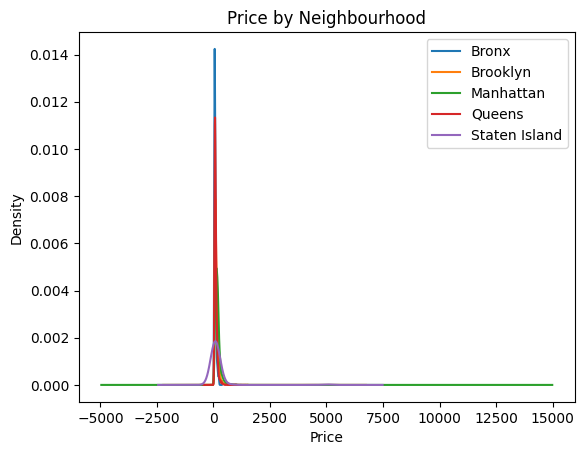

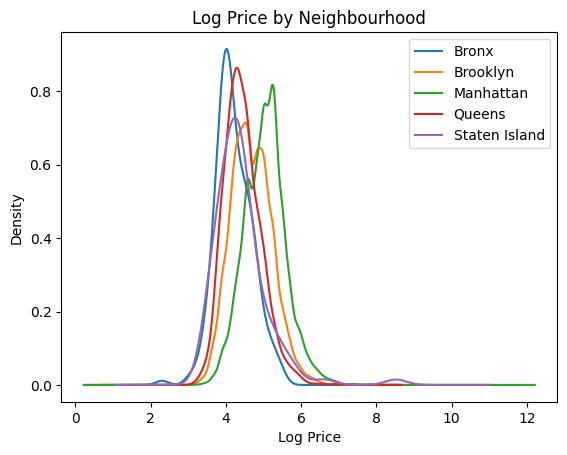

Intercept:  75.27649769584602  Coefficients:  [ 52.47088065 108.38778863  21.58073501  70.89016897]
Intercept:  60.87839065712386  Coefficients:  [1.0208266]
Intercept:  -23.81256101167307  Coefficients:  [  1.08111648  51.70424016 108.22873657  21.69459958  71.76655213]
Intercept:  55.11825364116282  Coefficients:  [0.2227179  0.79094703 1.39937639 0.45645133 0.68244398]
Model Three: Fold Scores:  [14525.62587895 18785.03156182 23315.65390815 21485.08112418
 17377.37412282 16911.65764952 66505.14612181 12010.92688963
 13867.65309739 16010.97323341]  Mean Score:  22079.51235876914  Median Score:  17144.515886169527  Std Dev:  15158.786803772264
Model Four: Fold Scores:  [13328.8844614  17923.91602978 22359.73425128 20638.78463036
 16213.77913811 15968.25148456 65543.4120206  11112.83183507
 12726.79546542 14924.58455652]  Mean Score:  21074.097387309375  Median Score:  16091.015311334519  Std Dev:  15184.49009301701
Model Five: Fold Scores:  [13311.07229932 17954.60039454 22387.1933701

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer

propertyData = pd.read_csv("./data/Q1_clean.csv")
print(propertyData.columns)

#2.1)
neighbourhoodAverages = propertyData.groupby("Neighbourhood ")[["Price", "Review Scores Rating"]].mean()
print(neighbourhoodAverages)
propertyData["logPrice"] = np.log(propertyData["Price"])
propertyData.groupby("Neighbourhood ")["Price"].plot.kde(legend = True)
plt.xlabel("Price")
plt.title("Price by Neighbourhood")
plt.show()
propertyData.groupby("Neighbourhood ")["logPrice"].plot.kde(legend = True)
plt.xlabel("Log Price")
plt.title("Log Price by Neighbourhood")
plt.show()

#2.2)
price = propertyData["Price"]
dummy = pd.get_dummies(propertyData["Neighbourhood "], drop_first = True)
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(dummy, price)
print("Intercept: ", regressionModel.intercept_, " Coefficients: ", regressionModel.coef_)

#2.3)
reviewScoresRating = propertyData[["Review Scores Rating"]]
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(reviewScoresRating, price)
print("Intercept: ", regressionModel.intercept_, " Coefficients: ", regressionModel.coef_)

#2.4)
regressionData = pd.concat([reviewScoresRating, dummy], axis = 1)
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(regressionData, price)
print("Intercept: ", regressionModel.intercept_, " Coefficients: ", regressionModel.coef_)

#2.5)
dummy = pd.get_dummies(propertyData["Neighbourhood "])
reviewScoresRating = propertyData["Review Scores Rating"]
for neighbourhood in dummy.columns:
    dummy[neighbourhood] = dummy[neighbourhood] * reviewScoresRating
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(dummy, price)
print("Intercept: ", regressionModel.intercept_, " Coefficients: ", regressionModel.coef_)

#2.6)
reviewScoresRating = propertyData[["Review Scores Rating"]]
scoringFunction = make_scorer(mean_squared_error)
kFold = KFold(n_splits = 10, shuffle = True, random_state = 100)
modelThreeScores = cross_val_score(LinearRegression(), reviewScoresRating, price, cv = kFold, scoring = scoringFunction)
modelFourScores = cross_val_score(LinearRegression(), regressionData, price, cv = kFold, scoring = scoringFunction)
modelFiveScores = cross_val_score(LinearRegression(), dummy, price, cv = kFold, scoring = scoringFunction)

print("Model Three: Fold Scores: ", modelThreeScores, " Mean Score: ", np.mean(modelThreeScores), " Median Score: ", np.median(modelThreeScores), " Std Dev: ", np.std(modelThreeScores))
print("Model Four: Fold Scores: ", modelFourScores, " Mean Score: ", np.mean(modelFourScores), " Median Score: ", np.median(modelFourScores), " Std Dev: ", np.std(modelFourScores))
print("Model Five: Fold Scores: ", modelFiveScores, " Mean Score: ", np.mean(modelFiveScores), " Median Score: ", np.median(modelFiveScores), " Std Dev: ", np.std(modelFiveScores))

## Question 2
#### 2.1) 
* Manhattan has the most expensive bourough.
#### 2.2)
* I dropped the first category (Bronx).
* The conditional group means and the estimated coefficients are related because the group mean is equal to the intercept plus the group's corresponding coefficient.
#### 2.3)
* The slope coefficient is 1.02, indicating that for every increase in 1 for review score rating price increases by $1.02 holding other variables constant.
#### 2.4)
* The slope coefficient on review scores rating changed by increasing from 1.02 to 1.08.
* The neighbourhood averages change by now accounting for review score rating, resulting in slight changes in neighbourhood coefficient values.
#### 2.5)
* The slopes still have enough variation between neighbourhoods to not be considered similar.
#### 2.6)
* By models for parts 4,5,6 I assumed that the models from 2.3, 2.4, and 2.5 are what is meant.
* Performance for Model Three: 
  - Fold Scores:  [14525.62587895 18785.03156182 23315.65390815 21485.08112418
   17377.37412282 16911.65764952 66505.14612181 12010.92688963
   13867.65309739 16010.97323341]  
  - Mean Score:  22079.51235876914  
  - Median Score:  17144.515886169527  
  - Std Dev:  15158.786803772264
* Performance for Model Four: 
  - Fold Scores:  [13328.8844614  17923.91602978 22359.73425128 20638.78463036
    16213.77913811 15968.25148456 65543.4120206  11112.83183507
    12726.79546542 14924.58455652]  
  - Mean Score:  21074.097387309375  
  - Median Score:  16091.015311334519  
  - Std Dev:  15184.49009301701
* Performance for Model Five:
  - Fold Scores:  [13311.07229932 17954.60039454 22387.19337011 20619.21550811
   16175.84243945 15946.8948861  65402.49266663 11078.49494357
   12712.73515709 14905.03305142]  
   - Mean Score:  21049.357471633  
   - Median Score:  16061.368662774745  
   - Std Dev:  15149.555684425926
* Model Five has the lowest mean score, meaning it performed the best.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


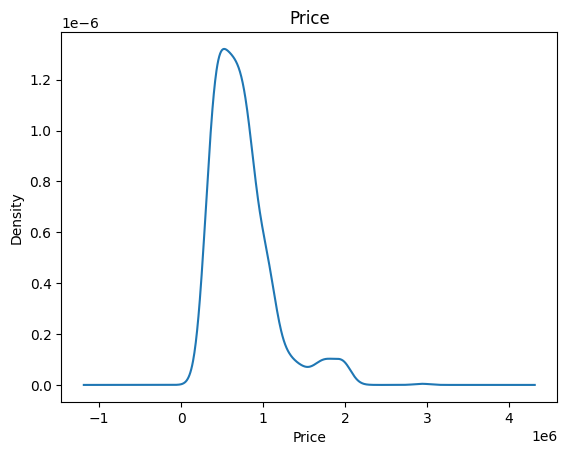

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


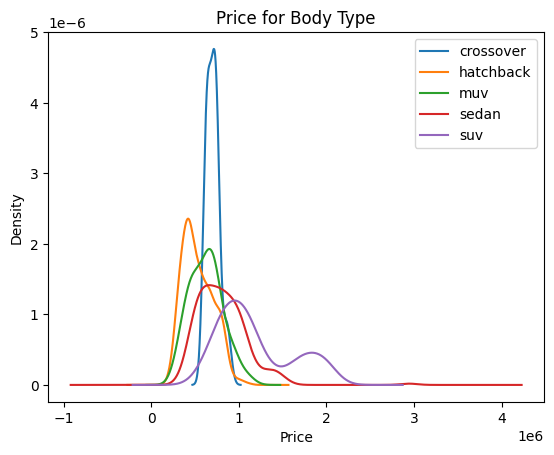

Intercept:  439032.0141018268  Coefficients:  [59267.99803672]
Intercept:  188000.00000000396  Coefficients:  [ 546483.87096774 1456000.          735948.71794872  271800.        ]
Model 1 : Fold Scores:  [9.05629877e+10 1.04590149e+11 8.35150173e+10 9.42889896e+10
 9.57961145e+10 8.23002081e+10 1.29209046e+11 1.10209665e+11
 7.53798399e+10 1.10087901e+11]  Mean Score:  97593991873.8482  Median Score:  95042552057.2941  Std Dev:  15339123765.102118
Model 2 : Fold Scores:  [9.20679097e+10 1.04305410e+11 8.32733403e+10 9.46507501e+10
 9.54563329e+10 8.20687850e+10 1.28878082e+11 1.10133254e+11
 7.60483282e+10 1.11005506e+11]  Mean Score:  97788769710.30014  Median Score:  95053541488.95712  Std Dev:  15213672749.608932
Model 3 : Fold Scores:  [9.11466665e+10 1.04301612e+11 8.26981277e+10 9.41662407e+10
 9.46269828e+10 7.93254512e+10 1.27564781e+11 1.10814361e+11
 7.64942125e+10 1.10689810e+11]  Mean Score:  97182824586.8537  Median Score:  94396611731.05702  Std Dev:  15332240768.01061
Mo

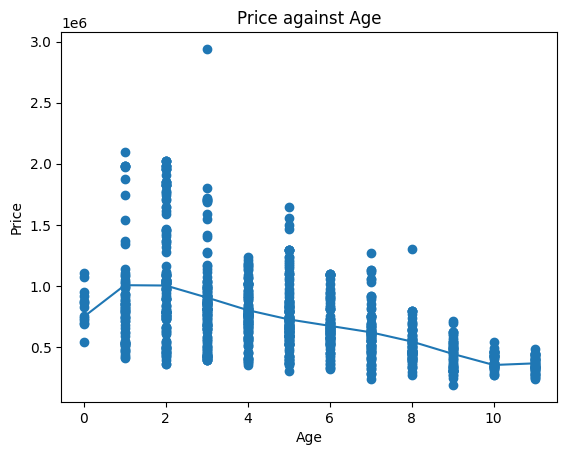

In [35]:
from sklearn.preprocessing import PolynomialFeatures

#3.1)
carsData = pd.read_csv("./data/cars_hw.csv")
print((carsData["Price"]).describe())
carsData["Price"].plot.kde()
plt.xlabel("Price")
plt.title("Price")
plt.show()
print(carsData.groupby("Body_Type")["Price"].describe())
carsData.groupby("Body_Type")["Price"].plot.kde(legend = True)
plt.xlabel("Price") 
plt.title("Price for Body Type") 
plt.show()

#3.2)
price = carsData["Price"]
seatingCapacity = carsData[["Seating_Capacity"]]
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(seatingCapacity, price)
print("Intercept: ", regressionModel.intercept_, " Coefficients: ", regressionModel.coef_)
dummy = pd.get_dummies(carsData["Seating_Capacity"], drop_first = True)
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(dummy, price)
print("Intercept: ", regressionModel.intercept_, " Coefficients: ", regressionModel.coef_)

#3.3)
carsData["age"] = carsData["Make_Year"].max() - carsData["Make_Year"]
age = carsData[["age"]]
scoringFunction = make_scorer(mean_squared_error)
kFold = KFold(n_splits = 10, shuffle = True, random_state = 100)

for i in range(1,7):
    expander = PolynomialFeatures(degree = i, include_bias = False)
    agePolynomial = expander.fit_transform(age)
    modelScores = cross_val_score(LinearRegression(), agePolynomial, price, cv = kFold, scoring = scoringFunction)
    print("Model", i,": Fold Scores: ", modelScores, " Mean Score: ", np.mean(modelScores), " Median Score: ", np.median(modelScores), " Std Dev: ", np.std(modelScores))

#3.4)
expander = PolynomialFeatures(degree = 5, include_bias = False)
agePolynomial = expander.fit_transform(age)
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(agePolynomial, price)
plt.scatter(carsData["age"], price)
plt.xlabel("Age") 
plt.ylabel("Price")
plt.title("Price against Age")
sortCarsData = carsData.sort_values("age")
age = sortCarsData[["age"]]
agePolynomial = expander.fit_transform(age)
plt.plot(sortCarsData["age"], regressionModel.predict(agePolynomial))
plt.show()


## Question 3
#### 3.1)
* SUVs are the most expensive car type.
* SUVs have the highest variance.
#### 3.2)
* The slope coefficient is 59267.10, indicating that for every increase in 1 for seating capacity price increases by 59267.10 rupees.
* The differences in price are not roughly linear in the number of seats as seen by the inconsistent differences in the coefficients.
#### 3.3)
* The optimal number of powers of age to include in a regression of price on age is 5 because it has the lowest mean score.
#### 3.4)
* The model somewhat fits the patterns in the data, but not perfectly. It captures the general trend though.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


0.23017902813299232
Intercept:  0.11764705882352941  Coefficients:  [0.23017903]
Intercept:  0.7019569721740948  Coefficients:  [ 0.26470169 -0.01360722]


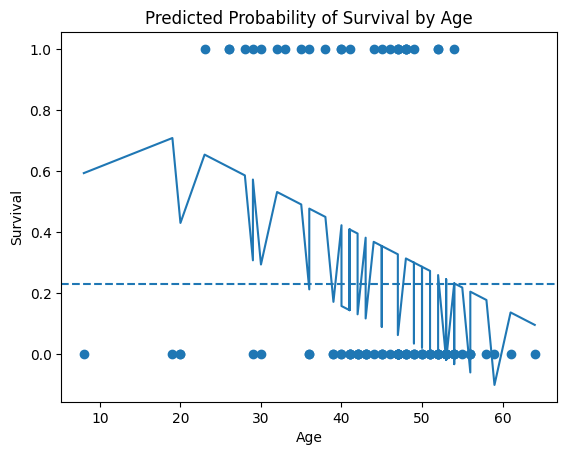

Intercept:  0.3548651752994586  Coefficients:  [ 0.90775139 -0.00552426 -0.01459064]


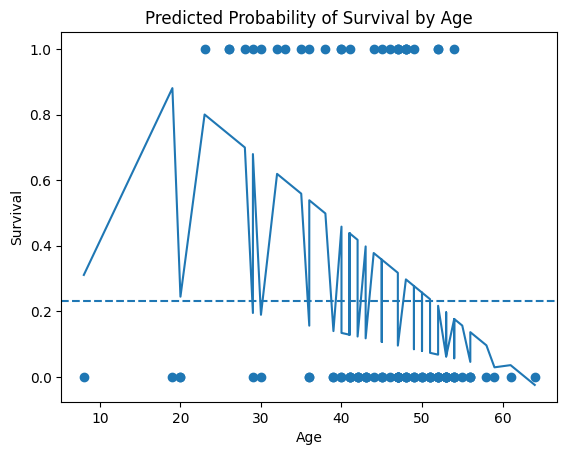

Model One: Fold Scores:  [0.18821929 0.09540463 0.25155303 0.18834547 0.27505257 0.17580257
 0.23480257 0.20624315 0.09155851 0.22965661]  Mean Score:  0.19366383979017968  Median Score:  0.1972943112160721  Std Dev:  0.05794714989607307
Model Two: Fold Scores:  [0.13199021 0.09724379 0.23532537 0.17986301 0.26846931 0.13026885
 0.15561234 0.21528362 0.17469232 0.22844789]  Mean Score:  0.18171967184387974  Median Score:  0.17727766476646972  Std Dev:  0.05167198499924281
Model Three: Fold Scores:  [0.13045006 0.09902894 0.233215   0.25380574 0.27583732 0.11557048
 0.12649585 0.20870022 0.14792529 0.21568012]  Mean Score:  0.18067090272965358  Median Score:  0.17831275470716956  Std Dev:  0.06050647919386988


In [49]:
heartData = pd.read_csv("./data/heart_hw.csv")

#4.1)
transplantData = heartData.groupby("transplant")["y"].mean()
a = transplantData["control"]
b = transplantData["treatment"]
ATE = b - a 
print(ATE)

#4.2)
dummy = pd.get_dummies(heartData["transplant"], drop_first = True)
y = heartData["y"]
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(dummy, y) 
print("Intercept: ", regressionModel.intercept_, " Coefficients: ", regressionModel.coef_)

#4.3)
age = heartData[["age"]]
regressionData = pd.concat([dummy, age], axis = 1)
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(regressionData, y)
print("Intercept: ", regressionModel.intercept_, " Coefficients: ", regressionModel.coef_)
plt.scatter(heartData["age"], y)
plt.ylabel("Survival") 
plt.xlabel("Age") 
plt.title("Predicted Probability of Survival by Age")
sortData = heartData.sort_values("age") 
sortAge = sortData[["age"]]
sortDummy = pd.get_dummies(sortData["transplant"], drop_first = True) 
sortRegressionData = pd.concat([sortDummy, sortAge], axis = 1) 
plt.plot(sortData["age"], regressionModel.predict(sortRegressionData))
plt.axhline(y = 0.23, linestyle = "dashed") 
plt.show()

#4.4)
transplantAge = dummy["treatment"] * heartData["age"]
transplantAge.name = "transplantAge"
regressionData = pd.concat([dummy, age, transplantAge], axis = 1)
regressionModel = LinearRegression()
regressionModel = regressionModel.fit(regressionData, y)
print("Intercept: ", regressionModel.intercept_, " Coefficients: ", regressionModel.coef_)
plt.scatter(heartData["age"], y)
plt.ylabel("Survival") 
plt.xlabel("Age") 
plt.title("Predicted Probability of Survival by Age")
sortData = heartData.sort_values("age") 
sortAge = sortData[["age"]]
sortDummy = pd.get_dummies(sortData["transplant"], drop_first = True) 
sortTransplantAge = sortDummy["treatment"] * sortData["age"]
sortTransplantAge.name = "transplantAge"
sortRegressionData = pd.concat([sortDummy, sortAge, sortTransplantAge], axis = 1) 
plt.plot(sortData["age"], regressionModel.predict(sortRegressionData))
plt.axhline(y = 0.23, linestyle = "dashed") 
plt.show()

#4.5)
kFold = KFold(n_splits = 10, shuffle = True, random_state = 100) 
modelOne = pd.get_dummies(heartData["transplant"], drop_first = True)
modelTwo = pd.concat([modelOne, age], axis = 1)
transplantAge = modelOne["treatment"] * heartData["age"]
transplantAge.name = "transplantAge"
modelThree = pd.concat([modelOne, age, transplantAge], axis = 1)
modelOneScores = cross_val_score(LinearRegression(), modelOne, y, cv = kFold, scoring = scoringFunction)
modelTwoScores = cross_val_score(LinearRegression(), modelTwo, y, cv = kFold, scoring = scoringFunction)
modelThreeScores = cross_val_score(LinearRegression(), modelThree, y, cv = kFold, scoring = scoringFunction)
print("Model One: Fold Scores: ", modelOneScores, " Mean Score: ", np.mean(modelOneScores), " Median Score: ", np.median(modelOneScores), " Std Dev: ", np.std(modelOneScores))
print("Model Two: Fold Scores: ", modelTwoScores, " Mean Score: ", np.mean(modelTwoScores), " Median Score: ", np.median(modelTwoScores), " Std Dev: ", np.std(modelTwoScores))
print("Model Three: Fold Scores: ", modelThreeScores, " Mean Score: ", np.mean(modelThreeScores), " Median Score: ", np.median(modelThreeScores), " Std Dev: ", np.std(modelThreeScores))

## Question 4
#### 4.1)
* The ATE for three year survival on heart transplant interventions is 0.23.
#### 4.2)
* The coefficient value paired with the intercept matches the ATE value of 0.23 I got in part 1.
#### 4.3)
* The coefficient on transplant increased from 0.23 to 0.26 when I controlled for age.
* The intercept represents the likelihood that someone survives when age and transplant equal 0. The slope represents the change in likelihood that someone survives by receiving a transplant while holding age constant.
* For younger ages ATE underestimates the impact of a transplant and for older ages ATE overestimates the impact of a transplant.
#### 4.4)
* Allowing age and transplant to interact changes my predictions by resulting in survival decreasing at a steeper rate due to a change in slope as a result of age now playing a role. A pattern I notice is that while the second graph decreases more quickly than the first, they both still exhibit the same pattern of survival decreasing with age.
#### 4.5)
* Based on the outputs of the three models, model three has the best predictive accuracy due to it having the lowest mean squared error. This indicates that adding age improves predictive accuracy, and then adding transplant * age increases predictive accuracy even further accross the models.
#### 4.6)
* My concerns about model construction and deployment are the the possibility that the model lacks a complete and accurate set of data, resulting in bias that negatively impacts patients. Additionally, when it comes to something as critical as a heart transplant, a model cannot always make the best decision in the moment, causing scenarios where it makes the wrong decision. Overall, while the model is good at identifying general trends on past data, it is not equipped to make accurate decisions for present circumstances without guaranteeing a lack of bias or inaccuracy.